# 11 - Shift Spectra by Radial Velocity

This notebook explores how to shift stellar spectra according to their measured radial velocities (RV). The goal is to:

- Visually inspect how much spectral lines move across epochs
- Understand how RV correction aligns spectra into a common rest frame
- Prepare functions for shifting wavelength grids and interpolating flux
- Verify if line asymmetries or activity features remain after RV correction

**Note**: This is a diagnostic notebook, not part of the final pipeline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.constants import c
from scipy.interpolate import interp1d
import os

Convert the speed of light c from astropy.constants into kilometers per second (km/s) and extract its numerical value:

In [2]:
c_kms = c.to('km/s').value

## 1. Load One Spectrum and Its Metadata

We first load one FITS file from the VIS_A folder to examine the wavelength and flux arrays. We also load the metadata containing RV values.

In [3]:
VALID_ORDERS = list(range(17, 39))

with open("../../aumicAE/data/carvis_visA/vis_a_files.txt", "r") as f:
    vis_a_files = ["../../aumicAE/" + line.strip().lstrip("../") for line in f if line.strip()]

meta = pd.read_csv("../outputs/aligned_metadata/aligned_metadata.csv").sort_values("BJD").reset_index(drop=True)

with fits.open(vis_a_files[0]) as hdul:
    wave_data = hdul["WAVE"].data

print("Number of files:", len(vis_a_files))

Number of files: 95


## 2. Define RV Shift

The following function applies a Doppler shift to the wavelength grid using the given RV.

In [4]:
def doppler_shift(wave, rv_kms):
    beta = rv_kms / c_kms
    gamma = np.sqrt((1 + beta) / (1 - beta))
    return wave * gamma

## 3. Visualize Shift for a Single Spectrum

We choose one spectrum and one order and visualize:
- Original wavelength vs. flux
- RV-shifted wavelength vs. flux

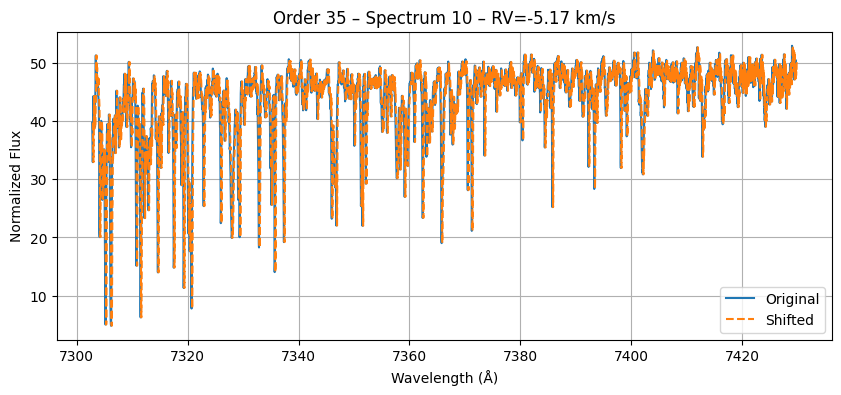

In [20]:
idx = 10  # example index
order = 35
rv = meta.loc[idx, "RV"]  # should be in km/s

with fits.open(vis_a_files[idx]) as hdul:
    wave = hdul["WAVE"].data[order]
    flux = hdul["SPEC"].data[order]
    cont = hdul["CONT"].data[order]
    norm_flux = flux / np.clip(cont, 1e-3, np.inf)

shifted_wave = doppler_shift(wave, -rv)

plt.figure(figsize=(10, 4))
plt.plot(wave, norm_flux, label="Original")
plt.plot(shifted_wave, norm_flux, label="Shifted", linestyle='--')
plt.xlabel("Wavelength (Å)")
plt.ylabel("Normalized Flux")
plt.title(f"Order {order} – Spectrum {idx} – RV={rv:.2f} km/s")
plt.legend()
plt.grid()
plt.show()

## 4. Interpolation Test to a Common Grid

In the final pipeline, we want to resample all spectra to a fixed wavelength grid after RV correction. We test this interpolation here.

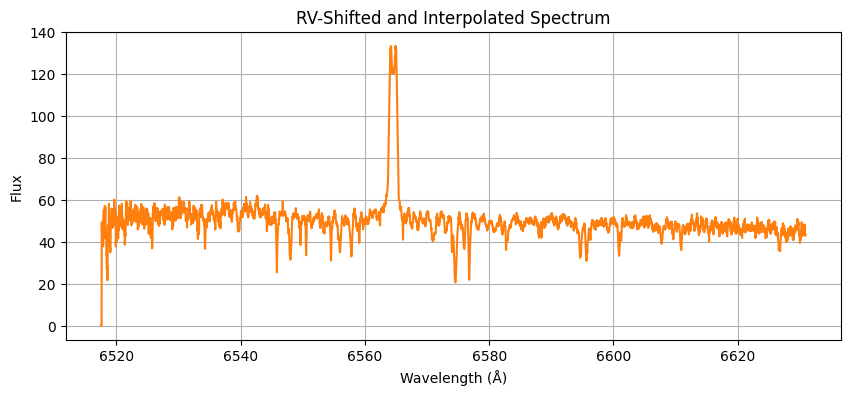

In [13]:
common_wave = np.linspace(wave_data[order][0], wave_data[order][-1], len(wave_data[order]))

interp_func = interp1d(shifted_wave, norm_flux, kind='linear', bounds_error=False, fill_value=0.0)
resampled_flux = interp_func(common_wave)

plt.figure(figsize=(10, 4))
plt.plot(common_wave, resampled_flux, label="Resampled", color="tab:orange")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("RV-Shifted and Interpolated Spectrum")
plt.grid()
plt.show()